# 1 - Importing Libraries

In [ ]:
import sys
import os

# Adicionar o caminho pai ao sys.path
sys.path.insert(0, os.path.abspath('..'))

from commons.utils import barplot_column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dotenv import load_dotenv 

from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [ ]:
load_dotenv()
LOCAL_PATH = os.getenv("LOCAL_PATH")

## 1.1 - Functions

# 2 - Loading databases

In [128]:
path_df_preprocessed = "preprocessed_data.parquet"
path_X = "X_data.parquet"
path_y = "y_data.parquet"
path_X_val = "X_val.parquet"
path_y_val = "y_val.parquet"

In [129]:
df_res_pub_final = pd.read_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_df_preprocessed}")
X_data = pd.read_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_X}")
y_data = pd.read_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_y}")
X_val = pd.read_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_X_val}")
y_val = pd.read_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_y_val}")

KeyboardInterrupt: 

In [ ]:
df_res_pub_final

,Age,EdLevel,WorkExp,LearnCodeChoose,LearnCodeAI,YearsCode,DevType,OrgSize,RemoteWork,Industry,...,ai_agent_external_Lovable.dev,ai_agent_external_Microsoft Copilot,ai_agent_external_OpenHands (formerly OpenDevin),ai_agent_external_Perplexity,ai_agent_external_Replit,ai_agent_external_Roo code (Roo-Cline),ai_agent_external_Tabnine,ai_agent_external_v0.dev,MinimumWageAnnual,ConvertedCompYearly_log
0,25-34 years old,0.857143,0.118644,1,1.0,0.209677,"Developer, mobile",0.375,0.8,Fintech,...,0,0,0,0,0,0,0,0,2946.0,11.022833
1,25-34 years old,0.571429,0.016949,1,1.0,0.145161,"Developer, back-end",0.625,0.6,Retail and Consumer Services,...,0,0,0,0,0,0,0,0,24925.0,11.556119
2,35-44 years old,0.714286,0.152542,1,1.0,0.177419,"Developer, front-end",0.000,0.0,Software Development,...,0,0,0,0,0,0,0,0,2946.0,10.879216
3,35-44 years old,0.714286,0.050847,1,1.0,0.064516,"Developer, back-end",1.000,0.8,Retail and Consumer Services,...,0,0,0,0,0,0,0,0,2946.0,10.496759
4,35-44 years old,0.857143,0.338983,0,1.0,0.338710,Engineering manager,0.000,0.0,Software Development,...,0,0,0,0,0,0,0,0,2946.0,11.002117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19105,35-44 years old,0.857143,0.220339,1,1.0,0.209677,"Developer, back-end",0.500,1.0,Fintech,...,0,0,0,0,0,0,0,0,0.0,12.043560
19106,35-44 years old,0.857143,0.305085,1,0.0,0.370968,"Senior executive (C-suite, VP, etc.)",0.250,0.6,Software Development,...,0,0,0,0,0,0,0,0,0.0,11.629241
19107,25-34 years old,0.714286,0.067797,0,1.0,0.145161,"Developer, mobile",0.375,0.4,Software Development,...,0,0,0,0,0,0,0,0,24925.0,10.805821
19108,25-34 years old,0.714286,0.050847,0,1.0,0.080645,"Developer, full-stack",0.750,0.6,Fintech,...,0,1,0,0,0,0,0,0,674.0,9.640823


In [ ]:
columns_to_drop = ["Age",
"EdLevel",
"LearnCodeChoose",
"LearnCodeAI",
"DevType",
"OrgSize",
"RemoteWork",
"Industry",
"NewRole",
"Country",
"LanguageHaveWorkedWith",
"DatabaseChoice",
"DatabaseHaveWorkedWith",
"PlatformChoice",
"PlatformHaveWorkedWith",
"WebframeChoice",
"WebframeHaveWorkedWith",
"DevEnvsChoice",
"DevEnvsHaveWorkedWith",
"OpSysProfessional use",
"OfficeStackAsyncHaveWorkedWith",
"CommPlatformHaveWorkedWith",
"AIModelsChoice",
"AIModelsHaveWorkedWith",
"AISelect",
"AIToolCurrently partially AI",
"AIToolDon't plan to use AI for this task",
"AIToolPlan to partially use AI",
"AIToolPlan to mostly use AI",
"AIToolCurrently mostly AI",
"AIAgentImpactSomewhat agree",
"AIAgentImpactNeutral",
"AIAgentImpactSomewhat disagree",
"AIAgentImpactStrongly agree",
"AIAgentImpactStrongly disagree",
"AIAgentChallengesNeutral",
"AIAgentChallengesSomewhat disagree",
"AIAgentChallengesStrongly agree",
"AIAgentChallengesSomewhat agree",
"AIAgentChallengesStrongly disagree",
"AIAgentKnowledge",
"AIAgentOrchestration",
"AIAgentObserveSecure",
"AIAgentExternal",
"MinimumWageAnnual",
"treatedCountry",
"ConvertedCompYearly"]

In [ ]:
df_full = df_res_pub_final.drop(columns=columns_to_drop, axis=1)

In [ ]:
correlation_matrix = df_full.corr()

In [ ]:
# 2. Compute the correlation matrix for numeric columns
# The .corr() method calculates the Pearson correlation coefficient by default
corr_matrix = df_full.select_dtypes('number').corr()

In [ ]:
corr_matrix.shape

(521, 521)

In [ ]:
cols = ['WorkExp',
        'YearsCode',
        'ToolCountWork',
        'gdp_per_capita',
        'WorkExp_log',
        'YearsCode_log',
        'ToolCountWork_w',
        'ToolCountWork_log',
        'ConvertedCompYearly_log']

In [ ]:
features = [
    "WorkExp",
    "YearsCode",
    "ToolCountWork",
    "age_cat_18-24 years old",
    "age_cat_25-34 years old",
    "age_cat_35-44 years old",
    "age_cat_45-54 years old",
    "age_cat_55-64 years old",
    "age_cat_65 years or older",
    "age_cat_Prefer not to say",
    "gdp_per_capita",
    "WorkExp_log",
    "YearsCode_log",
    "dev_type__AI/ML engineer",
    "dev_type__Academic researcher",
    "dev_type__Applied scientist",
    "dev_type__Architect, software or solutions",
    "dev_type__Cloud infrastructure engineer",
    "dev_type__Cybersecurity or InfoSec professional",
    "dev_type__Data engineer",
    "dev_type__Data or business analyst",
    "dev_type__Data scientist",
    "dev_type__Database administrator or engineer",
    "dev_type__DevOps engineer or professional",
    "dev_type__Developer, AI apps or physical AI",
    "dev_type__Developer, QA or test",
    "dev_type__Developer, back-end",
    "dev_type__Developer, desktop or enterprise applications",
    "dev_type__Developer, embedded applications or devices",
    "dev_type__Developer, front-end",
    "dev_type__Developer, full-stack",
    "dev_type__Developer, game or graphics",
    "dev_type__Developer, mobile",
    "dev_type__Engineering manager",
    "dev_type__Financial analyst or engineer",
    "dev_type__Founder, technology or otherwise",
    "dev_type__Other (please specify):",
    "dev_type__Product manager",
    "dev_type__Project manager",
    "dev_type__Senior executive (C-suite, VP, etc.)",
    "dev_type__Support engineer or analyst",
    "dev_type__System administrator",
    "dev_type__UX, Research Ops or UI design professional",
    "industry__Banking/Financial Services",
    "industry__Computer Systems Design and Services",
    "industry__Energy",
    "industry__Fintech",
    "industry__Government",
    "industry__Healthcare",
    "industry__Higher Education",
    "industry__Insurance",
    "industry__Internet, Telecomm or Information Services",
    "industry__Manufacturing",
    "industry__Media & Advertising Services",
    "industry__Other:",
    "industry__Retail and Consumer Services",
    "industry__Software Development",
    "industry__Transportation, or Supply Chain",
    "ToolCountWork_w",
    "ToolCountWork_log",
    "lang_Ada",
    "lang_Assembly",
    "lang_Bash/Shell (all shells)",
    "lang_C",
    "lang_C#",
    "lang_C++",
    "lang_COBOL",
    "lang_Dart",
    "lang_Delphi",
    "lang_Elixir",
    "lang_Erlang",
    "lang_F#",
    "lang_Fortran",
    "lang_GDScript",
    "lang_Gleam",
    "lang_Go",
    "lang_Groovy",
    "lang_HTML/CSS",
    "lang_Java",
    "lang_JavaScript",
    "lang_Kotlin",
    "lang_Lisp",
    "lang_Lua",
    "lang_MATLAB",
    "lang_MicroPython",
    "lang_Mojo",
    "lang_OCaml",
    "lang_PHP",
    "lang_Perl",
    "lang_PowerShell",
    "lang_Prolog",
    "lang_Python",
    "lang_R",
    "lang_Ruby",
    "lang_Rust",
    "lang_SQL",
    "lang_Scala",
    "lang_Swift",
    "lang_TypeScript",
    "lang_VBA",
    "lang_Visual Basic (.Net)",
    "lang_Zig",
    "db_Amazon Redshift",
    "db_BigQuery",
    "db_Cassandra",
    "db_Clickhouse",
    "db_Cloud Firestore",
    "db_Cockroachdb",
    "db_Cosmos DB",
    "db_Databricks SQL",
    "db_Datomic",
    "db_DuckDB",
    "db_Dynamodb",
    "db_Elasticsearch",
    "db_Firebase Realtime Database",
    "db_H2",
    "db_IBM DB2",
    "db_InfluxDB",
    "db_MariaDB",
    "db_Microsoft Access",
    "db_Microsoft SQL Server",
    "db_MongoDB",
    "db_MySQL",
    "db_Neo4J",
    "db_Oracle",
    "db_Pocketbase",
    "db_PostgreSQL",
    "db_Redis",
    "db_SQLite",
    "db_Snowflake",
    "db_Supabase",
    "db_Valkey",
    "platform_APT",
    "platform_Amazon Web Services (AWS)",
    "platform_Ansible",
    "platform_Bun",
    "platform_Cargo",
    "platform_Chocolatey",
    "platform_Cloudflare",
    "platform_Composer",
    "platform_Datadog",
    "platform_Digital Ocean",
    "platform_Docker",
    "platform_Firebase",
    "platform_Google Cloud",
    "platform_Gradle",
    "platform_Heroku",
    "platform_Homebrew",
    "platform_IBM Cloud",
    "platform_Kubernetes",
    "platform_MSBuild",
    "platform_Make",
    "platform_Maven (build tool)",
    "platform_Microsoft Azure",
    "platform_Netlify",
    "platform_New Relic",
    "platform_Ninja",
    "platform_NuGet",
    "platform_Pacman",
    "platform_Pip",
    "platform_Podman",
    "platform_Poetry",
    "platform_Prometheus",
    "platform_Railway",
    "platform_Splunk",
    "platform_Supabase",
    "platform_Terraform",
    "platform_Vercel",
    "platform_Vite",
    "platform_Webpack",
    "platform_Yandex Cloud",
    "platform_Yarn",
    "platform_npm",
    "platform_pnpm",
    "webframes_ASP.NET",
    "webframes_ASP.NET Core",
    "webframes_Angular",
    "webframes_AngularJS",
    "webframes_Astro",
    "webframes_Axum",
    "webframes_Blazor",
    "webframes_Deno",
    "webframes_Django",
    "webframes_Drupal",
    "webframes_Express",
    "webframes_FastAPI",
    "webframes_Fastify",
    "webframes_Flask",
    "webframes_Laravel",
    "webframes_NestJS",
    "webframes_Next.js",
    "webframes_Node.js",
    "webframes_Nuxt.js",
    "webframes_Phoenix",
    "webframes_React",
    "webframes_Ruby on Rails",
    "webframes_Spring Boot",
    "webframes_Svelte",
    "webframes_Symfony",
    "webframes_Vue.js",
    "webframes_WordPress",
    "webframes_jQuery",
    "devenvs_Aider",
    "devenvs_Android Studio",
    "devenvs_Bolt",
    "devenvs_Claude Code",
    "devenvs_Cline and/or Roo",
    "devenvs_Cursor",
    "devenvs_Eclipse",
    "devenvs_IntelliJ IDEA",
    "devenvs_Jupyter Notebook/JupyterLab",
    "devenvs_Lovable.dev",
    "devenvs_Nano",
    "devenvs_Neovim",
    "devenvs_Notepad++",
    "devenvs_PhpStorm",
    "devenvs_PyCharm",
    "devenvs_Rider",
    "devenvs_RustRover",
    "devenvs_Sublime Text",
    "devenvs_Trae",
    "devenvs_VSCodium",
    "devenvs_Vim",
    "devenvs_Visual Studio",
    "devenvs_Visual Studio Code",
    "devenvs_WebStorm",
    "devenvs_Windsurf",
    "devenvs_Xcode",
    "devenvs_Zed",
    "os_Android",
    "os_Arch",
    "os_ChromeOS",
    "os_Debian",
    "os_Fedora",
    "os_Linux (non-WSL)",
    "os_MacOS",
    "os_NixOS",
    "os_Pop!_OS",
    "os_Red Hat",
    "os_Ubuntu",
    "os_Windows",
    "os_Windows Subsystem for Linux (WSL)",
    "os_iOS",
    "os_iPadOS",
    "office_stack_Airtable",
    "office_stack_Asana",
    "office_stack_Azure Devops",
    "office_stack_Clickup",
    "office_stack_Coda",
    "office_stack_Confluence",
    "office_stack_Doxygen",
    "office_stack_GitHub",
    "office_stack_GitLab",
    "office_stack_Google Colab",
    "office_stack_Google Workspace",
    "office_stack_Jira",
    "office_stack_Linear",
    "office_stack_Lucid (includes Lucidchart)",
    "office_stack_Markdown File",
    "office_stack_Microsoft Planner",
    "office_stack_Miro",
    "office_stack_Monday.com",
    "office_stack_Notion",
    "office_stack_Obsidian",
    "office_stack_Redmine",
    "office_stack_Stack Overflow for Teams",
    "office_stack_Trello",
    "office_stack_Wikis",
    "office_stack_YouTrack",
    "community_Bluesky",
    "community_Company-sponsored forums",
    "community_Dev.to",
    "community_Discord",
    "community_GitHub (public projects, not private repos)",
    "community_Hacker News",
    "community_Hashnode",
    "community_Kaggle",
    "community_LinkedIn",
    "community_Medium",
    "community_Reddit",
    "community_Slack (public channels, not work)",
    "community_Stack Exchange",
    "community_Stack Overflow",
    "community_Substack",
    "community_Twitch",
    "community_X",
    "community_YouTube",
    "ai_worked_with_Alibaba Cloud Qwen models",
    "ai_worked_with_Amazon Titan models",
    "ai_worked_with_Anthropic: Claude Sonnet",
    "ai_worked_with_Cohere: Command A",
    "ai_worked_with_DeepSeek (R- Reasoning models)",
    "ai_worked_with_DeepSeek (V- General purpose models)",
    "ai_worked_with_Gemini (Flash general purpose models)",
    "ai_worked_with_Gemini (Pro Reasoning models)",
    "ai_worked_with_Meta Llama (all models)",
    "ai_worked_with_Microsoft Phi-4 models",
    "ai_worked_with_Mistral AI models",
    "ai_worked_with_Perplexity Sonar models",
    "ai_worked_with_Reka (Flash 3 or other Reka models)",
    "ai_worked_with_X Grok models",
    "ai_worked_with_openAI GPT (chatbot models)",
    "ai_worked_with_openAI Image generating models",
    "ai_worked_with_openAI Reasoning models"
]


In [ ]:
df_analysis = df_full[cols]

In [ ]:
corr_matrix = df_analysis.select_dtypes('number').corr()

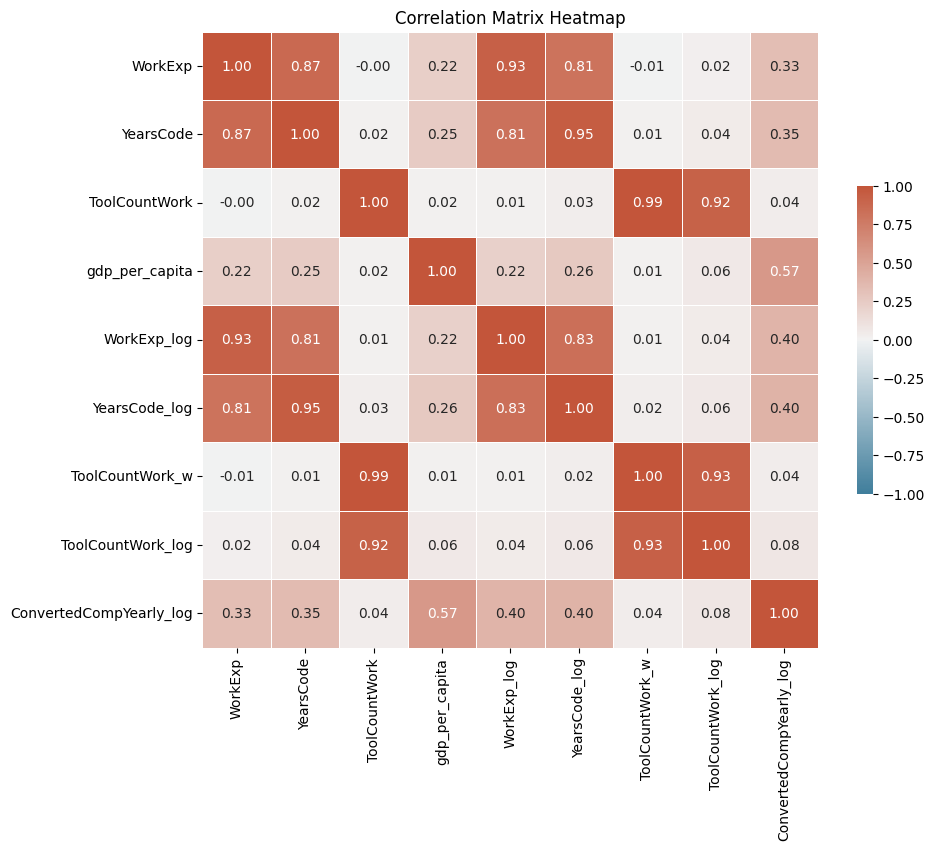

In [ ]:
# Set up the matplotlib figure and axes
plt.figure(figsize=(10, 8))

# Generate a custom diverging colormap (recommended for correlations centered at zero)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with customizations
sns.heatmap(
    corr_matrix,
    vmin=-1,        # Ensure color range is balanced from -1 to 1
    vmax=1,         # Ensure color range is balanced from -1 to 1
    center=0,       # Center the color scale at zero
    cmap=cmap,      # Use the custom colormap
    square=True,    # Ensure cells are square
    linewidths=.5,  # Add slight lines between cells
    annot=True,     # Annotate each cell with the correlation value
    fmt=".2f",      # Format annotations to two decimal places
    cbar_kws={"shrink": .5} # Shrink the color bar a bit
)

plt.title("Correlation Matrix Heatmap")
plt.show()

WorkExp, YearsCode, WorkExp_log and YearsCode_log have high correlation, hence we will only work with YearsCode_log, wich has one of the highest correlation with our target <br>

Furthermore, we will choose to work with ToolCountWork_log and drop ToolCountWork_w and ToolCountWork

In [ ]:
df_fs = df_res_pub_final[features]

In [ ]:
correlated_cols_to_drop = ['WorkExp', 'YearsCode', 'WorkExp_log', 'ToolCountWork_w', 'ToolCountWork']

In [ ]:
df_fs = df_fs.drop(correlated_cols_to_drop, axis=1)

# 3 - Modeling

## 3.0 - Splitting dataset in train and test

In [ ]:
X_fs = X_data[features]
X_fs = X_fs.drop(correlated_cols_to_drop, axis=1)
y_fs = y_data

In [ ]:
X_validation = X_val[features]
X_validation = X_validation.drop(correlated_cols_to_drop, axis=1)
y_validation = y_val

In [ ]:
# Splitting the Dataset
# 1) Train (80%) e Validation (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_fs, y_fs, test_size=0.2, random_state=42
)


## 3.1 - Models

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    # Métrica no espaço log
    rmse_log = root_mean_squared_error(y_test, y_pred_log)

    # Volta para escala original com proteção
    MAX_LOG = np.percentile(y_train, 99)  # melhor que número mágico

    y_pred_safe = np.expm1(np.clip(y_pred_log, None, MAX_LOG))
    y_true_safe = np.expm1(np.clip(y_test, None, MAX_LOG))

    rmse = root_mean_squared_error(y_true_safe, y_pred_safe)
    mae = mean_absolute_error(y_true_safe, y_pred_safe)

    return {
        "RMSE_log": rmse_log,
        "RMSE": rmse,
        "MAE": mae
    }


In [ ]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(
        model, X_train, X_test, y_train, y_test
    )

results


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\stackoverflow-udacity-project-course-2\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


KeyboardInterrupt: 

### 3.1.1 - Cross-validation

In [130]:
def evaluate_model_random_search(
    model,
    param_distributions,
    X_train,
    y_train,
    X_test,
    y_test,
    n_iter=20,
    cv_splits=5,
    random_state=42,
):
    cv = KFold(
        n_splits=cv_splits, shuffle=True, random_state=random_state
    )

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    # Predições
    y_pred_log = best_model.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    return {
        "best_params": search.best_params_,
        "RMSE_log_CV": -search.best_score_,
        "RMSE_log_test": root_mean_squared_error(
            y_test, y_pred_log
        ),
        "RMSE_test": root_mean_squared_error(
            y_true, y_pred
        ),
        "MAE_test": mean_absolute_error(y_true, y_pred),
    }


### XGBoost

In [131]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

In [132]:
xgb_param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
}


In [133]:
xgb_results = evaluate_model_random_search(
    model=xgb_model,
    param_distributions=xgb_param_dist,
    X_train=X_fs,
    y_train=y_fs,
    X_test=X_validation,
    y_test=y_validation,
    n_iter=25,
)

xgb_results


Fitting 5 folds for each of 25 candidates, totalling 125 fits


{'best_params': {'subsample': 0.8,
  'reg_lambda': 10.0,
  'reg_alpha': 1.0,
  'n_estimators': 800,
  'max_depth': 10,
  'learning_rate': 0.01,
  'colsample_bytree': 0.8},
 'RMSE_log_CV': np.float64(0.7031032800674438),
 'RMSE_log_test': 0.6677595973014832,
 'RMSE_test': 44836.859375,
 'MAE_test': 28258.140625}

### LightGBM

In [134]:
lgbm_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
)


In [135]:
lgbm_param_dist = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 5, 10, 20],
    "min_child_samples": [10, 20, 50],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}


In [136]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df


In [137]:
X_fs_lgbm = clean_feature_names(X_fs)
X_validation_lgbm = clean_feature_names(X_validation)


In [138]:
lgbm_results = evaluate_model_random_search(
    model=lgbm_model,
    param_distributions=lgbm_param_dist,
    X_train=X_fs_lgbm,
    y_train=y_fs,
    X_test=X_validation_lgbm,
    y_test=y_validation,
    n_iter=25,
)

lgbm_results


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 811
[LightGBM] [Info] Number of data points in the train set: 16243, number of used features: 297
[LightGBM] [Info] Start training from score 11.131116
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

{'best_params': {'subsample': 0.8,
  'num_leaves': 63,
  'n_estimators': 800,
  'min_child_samples': 20,
  'max_depth': 5,
  'learning_rate': 0.01,
  'colsample_bytree': 0.7},
 'RMSE_log_CV': np.float64(0.7051635191247669),
 'RMSE_log_test': 0.6701921743540262,
 'RMSE_test': 45963.70473592749,
 'MAE_test': 28882.153585016655}

## Refazer XGBOOST E LIGHTGBM sem normalizar e standardizar os dados

In [ ]:
xgb_results_model = xgb_model.set_params(**xgb_results["best_params"])

In [ ]:
xgb_results_model.fit(X_fs, y_fs)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_results_model.feature_importances_
}).sort_values("importance", ascending=False)

In [ ]:
lgbm_results_model = lgbm_model.set_params(**lgbm_results["best_params"])

In [ ]:
lgbm_results_model.fit(X_fs_lgbm, y_fs)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1052
[LightGBM] [Info] Number of data points in the train set: 16243, number of used features: 297
[LightGBM] [Info] Start training from score 11.131116
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [ ]:
lgbm_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_results_model.feature_importances_
}).sort_values("importance", ascending=False)

In [ ]:
comparison = (
    xgb_importance.head(20)
    .merge(
        lgbm_importance.head(20),
        on="feature",
        how="outer",
        suffixes=("_xgb", "_lgbm")
    )
    .fillna(0)
)

comparison


,feature,importance_xgb,importance_lgbm
0,ToolCountWork,0.000000,108.0
1,WorkExp,0.008430,252.0
2,WorkExp_log,0.012029,98.0
3,YearsCode,0.007748,230.0
4,YearsCode_log,0.013976,72.0
5,age_cat_Prefer not to say,0.016269,0.0
6,community_LinkedIn,0.000000,50.0
7,community_Reddit,0.000000,67.0
8,community_Stack Overflow,0.000000,39.0
9,community_YouTube,0.000000,39.0
